In [4]:
from md_Helpers.master_csv import (
    build_results_inventory_csv,
    inventory_result_files,
    summarize_results_inventory,
)

table = build_results_inventory_csv()
summary = summarize_results_inventory(table)


In [5]:
from md_Helpers import master_csv, paths

eos_master = master_csv.build_thermalization_master_csv(
    n_fcc_cells=30,
    output_name="thermalization_master_ncells_30.csv",
    n_last=100,
)

eos_path = paths.MASTER_CSVS_V3_ROOT / "thermalization_master_ncells_30.csv"
eos_path


PosixPath('/exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/thermalization_master_ncells_30.csv')

Thermalized state exists: checking phase separation.
Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Thermalized state good; continuing to cavitation.
Created new cavitation initial state
state_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_10.000/center_box/cavitation_initial.gsd
creation_metadata_path: /exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_10.000/center_box/cavitation_creation.hdf5
radius: 10.0
bubble_center: [0. 0. 0.]
particles_removed: 2987
N_before: 108000
N_after: 105013
rho_before: 0.7099999529577021
rho_after: 0.6903631949995108
Using GPU device
Final device: <hoomd.device.GPU object at 0x7fbbcb31fa10>
Start

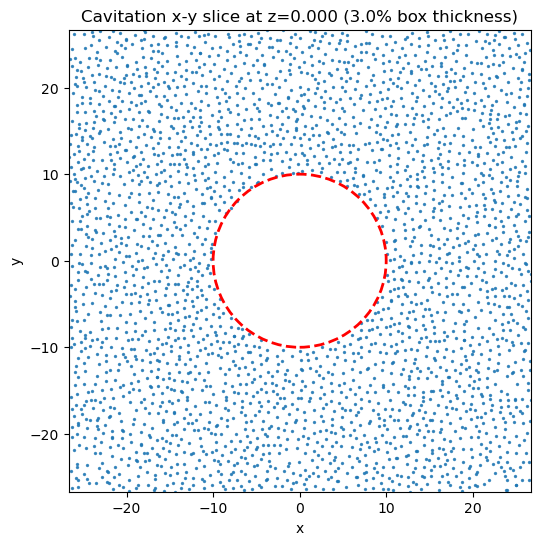

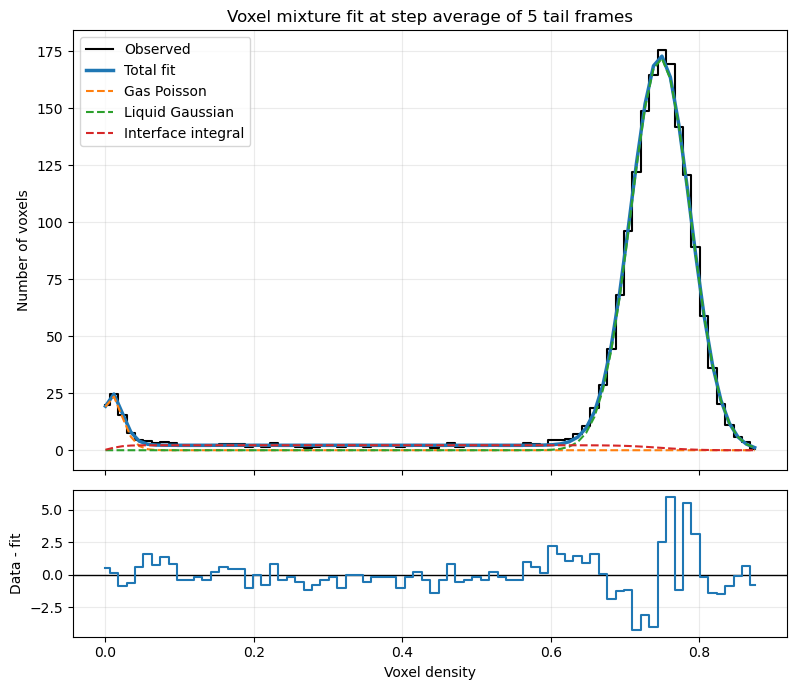

In [13]:
from md_Helpers import cavitation, seitz
from md_Helpers import visualization as vh

bubble = cavitation.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius=10.0,
    evolve_nsteps=100_000,
    evolve_seed=1,
)


vh.plot_cavitation_xy_slice(
    bubble["initial_result"],
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

check = vh.fit_and_animate_final_bubble(
    bubble,
    nbins=12,
    nframes=5,
    skip=5,
    tail_fraction=0.2,
)


if check["has_bubble"]:
    check["animation"]

In [14]:
check['fit']['liquid_density']

0.7478304751948642